<a href="https://colab.research.google.com/github/IvanMalkS/IS/blob/master/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа: Базовый конвейер ML для прогнозирования оттока
## 1. Загрузка и первичный осмотр данных
Импортируем необходимые библиотеки, загружаем датасет `telecom_churn.csv` и приводим целевую колонку к стандартному имени `Churn`. В качестве результата выведем первые 5 строк таблицы для визуального ознакомления.

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [53]:

df = pd.read_csv('telecom_churn.csv')

churn_col = [col for col in df.columns if 'churn' in col.lower()][0]
df.rename(columns={churn_col: 'Churn'}, inplace=True)

df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 2. Разбор данных: пропуски и типы
Проверим размерность нашего датасета и убедимся, что в данных нет пропущенных значений (NaN). Для наглядности выведем количество пропусков по каждому столбцу в виде таблицы.

In [54]:
df['Churn'] = df['Churn'].astype(int)

print(f"Размер датасета: {df.shape[0]} строк и {df.shape[1]} столбцов.")

df.isna().sum().to_frame(name='Количество пропусков').T

Размер датасета: 3333 строк и 21 столбцов.


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,Churn
Количество пропусков,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Анализ целевой переменной (Churn)
Посмотрим на баланс классов. Сколько клиентов ушло, а сколько осталось? Это важно знать, так как сильный дисбаланс влияет на то, как модель будет обучаться.

In [55]:
churn_counts = df['Churn'].value_counts().to_frame(name='Количество клиентов')
churn_counts.index =['Остался (0)', 'Ушел (1)']

churn_counts['Доля (%)'] = (churn_counts['Количество клиентов'] / len(df) * 100).round(1)

churn_counts

,Количество клиентов,Доля (%)
Остался (0),2850,85.5
Ушел (1),483,14.5


## 4. Подготовка данных: Разделение выборок
Разделим данные на признаки (X) и целевую переменную (Y).

Колонку `phone number` мы удаляем, так как это просто уникальный идентификатор, который не несет пользы для алгоритма и может привести к переобучению.
Далее разбиваем данные на тренировочную (75%) и тестовую (25%) выборки.

In [56]:
X = df.drop(['Churn', 'phone number'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

split_info = {
    'Название выборки': ['Обучающие признаки (X_train)', 'Тестовые признаки (X_test)',
                         'Обучающие метки (y_train)', 'Тестовые метки (y_test)'],
    'Количество строк': [X_train.shape[0], X_test.shape[0], y_train.shape[0], y_test.shape[0]],
    'Количество столбцов': [X_train.shape[1], X_test.shape[1], 1, 1]
}

pd.DataFrame(split_info).set_index('Название выборки')

,Количество строк,Количество столбцов
Название выборки,,
Обучающие признаки (X_train),2499,19
Тестовые признаки (X_test),834,19
Обучающие метки (y_train),2499,1
Тестовые метки (y_test),834,1


## 5. Предобработка: Масштабирование и кодирование
Создаем конвейер (`ColumnTransformer`). Числовые колонки приводим к одному масштабу с помощью `StandardScaler`. Категориальные (текстовые) колонки преобразуем в нули и единицы с помощью `OneHotEncoder`.

In [57]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'bool']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

transform_info = {
    'Параметр': [
        'Количество признаков до обработки',
        'Количество признаков после обработки',
        'Размер тренировочного набора',
        'Размер тестового набора'
    ],
    'Значение': [
        len(X.columns),
        X_train_processed.shape[1],
        str(X_train_processed.shape),
        str(X_test_processed.shape)
    ]
}

pd.DataFrame(transform_info).set_index('Параметр')

,Значение
Параметр,
Количество признаков до обработки,19
Количество признаков после обработки,68
Размер тренировочного набора,"(2499, 68)"
Размер тестового набора,"(834, 68)"


## 6. Обучение моделей и оценка точности
Инициализируем три алгоритма: логистическую регрессию, дерево решений и метод k-ближайших соседей. Обучаем каждую на `X_train_processed` и делаем предсказания на `X_test_processed`. Результаты собираем в единую таблицу.

### Преобразование в тензоры

In [58]:
X_train_t = torch.FloatTensor(X_train_processed.toarray() if hasattr(X_train_processed, 'toarray') else X_train_processed)
y_train_t = torch.LongTensor(y_train.values)
X_test_t = torch.FloatTensor(X_test_processed.toarray() if hasattr(X_test_processed, 'toarray') else X_test_processed)
y_test_t = torch.LongTensor(y_test.values)

input_dim = X_train_t.shape[1]

### 1. Logistic Regression


In [59]:
class PyTorchLogReg(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 2)

    def forward(self, x):
        return self.linear(x)

lr_model = PyTorchLogReg(input_dim)
optimizer = optim.Adam(lr_model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(100):
    optimizer.zero_grad()
    outputs = lr_model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

2. Desision tree

In [60]:
class TorchDecisionTree:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.tree = None

    def _entropy(self, y):
        if len(y) == 0: return 0
        p = torch.bincount(y).float() / len(y)
        p = p[p > 0]
        return -torch.sum(p * torch.log2(p))

    def _split(self, X, y, feature_idx, threshold):
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]

    def _best_split(self, X, y):
        best_gain = -1
        split_idx, split_thresh = None, None

        parent_entropy = self._entropy(y)
        n_features = X.shape[1]

        for feat_idx in range(n_features):
            thresholds = torch.unique(X[:, feat_idx])
            for thresh in thresholds:
                _, _, y_l, y_r = self._split(X, y, feat_idx, thresh)
                if len(y_l) == 0 or len(y_r) == 0: continue

                n = len(y)
                child_entropy = (len(y_l)/n) * self._entropy(y_l) + (len(y_r)/n) * self._entropy(y_r)
                ig = parent_entropy - child_entropy

                if ig > best_gain:
                    best_gain, split_idx, split_thresh = ig, feat_idx, thresh
        return split_idx, split_thresh

    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(torch.unique(y)) == 1 or len(y) < 2:
            return torch.mode(y).values.item()

        idx, thresh = self._best_split(X, y)
        if idx is None: return torch.mode(y).values.item()

        X_l, X_r, y_l, y_r = self._split(X, y, idx, thresh)
        return {
            'feature': idx,
            'threshold': thresh,
            'left': self._build_tree(X_l, y_l, depth + 1),
            'right': self._build_tree(X_r, y_r, depth + 1)
        }

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def _predict_one(self, x, tree):
        if not isinstance(tree, dict): return tree
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_one(x, tree['left'])
        else:
            return self._predict_one(x, tree['right'])

    def predict(self, X):
        return torch.tensor([self._predict_one(x, self.tree) for x in X])

torch_tree = TorchDecisionTree(max_depth=5)
torch_tree.fit(X_train_t, y_train_t)

y_pred_tree = torch_tree.predict(X_test_t)
acc_tree = (y_pred_tree == y_test_t).float().mean().item()

print(f"Accuracy Torch Decision Tree: {acc_tree:.4f}")

Accuracy Torch Decision Tree: 0.9341


### 3. K-Nearest Neighbors

In [61]:
def pytorch_knn(X_train, y_train, X_test, k=5):
    dist = torch.cdist(X_test, X_train)

    _, indices = dist.topk(k, largest=False)

    neighbor_labels = y_train[indices]
    predictions, _ = torch.mode(neighbor_labels, dim=1)
    return predictions

In [62]:
results_list = []

# 1. Тест Logistic Regression
lr_model.eval()
with torch.no_grad():
    preds = torch.argmax(lr_model(X_test_t), dim=1)
    results_list.append({'Модель': 'PyTorch LogReg', 'Accuracy': (preds == y_test_t).float().mean().item()})

# 2. Тест Tree
results_list.append({'Модель': 'PyTorch Decision Tree', 'Accuracy': acc_tree})

# 3. Тест KNN
knn_preds = pytorch_knn(X_train_t, y_train_t, X_test_t, k=5)
results_list.append({'Модель': 'PyTorch KNN', 'Accuracy': (knn_preds == y_test_t).float().mean().item()})

results_df = pd.DataFrame(results_list).sort_values(by='Accuracy', ascending=False)
results_df

,Модель,Accuracy
1,PyTorch Decision Tree,0.934053
2,PyTorch KNN,0.883693
0,PyTorch LogReg,0.865707


## 7. Визуализация результатов сравнения
Построим столбчатую диаграмму, чтобы наглядно увидеть победителя по метрике Accuracy.

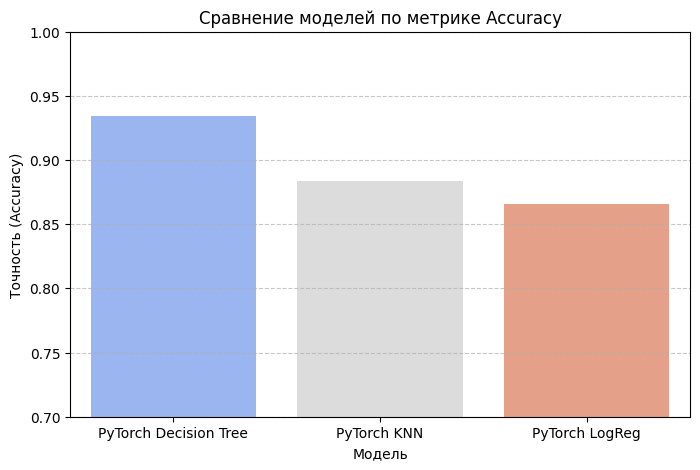

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(x='Модель', y='Accuracy', data=results_df, palette='coolwarm', hue='Модель', legend=False)

plt.title('Сравнение моделей по метрике Accuracy')
plt.ylim(0.7, 1.0)
plt.ylabel('Точность (Accuracy)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 8. Матрица ошибок лучшей модели
Из таблицы выше видно, какая модель справилась лучше всех. Построим для неё матрицу ошибок, чтобы понять, где именно она ошибается: пропускает ушедших или ложно обвиняет лояльных.

И выгрузим модельку для следующих лаб

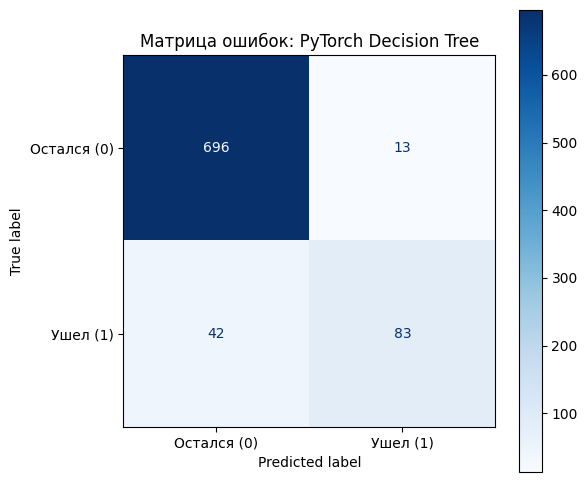

Результат: Лучшая модель — PyTorch Decision Tree. Файл сохранен.


In [64]:
best_model_name = results_df.iloc[0]['Модель']

if best_model_name == 'PyTorch Decision Tree':
    y_pred_best = torch_tree.predict(X_test_t).numpy()
    joblib.dump(torch_tree, 'best_model_lab1.pkl')

elif best_model_name == 'PyTorch KNN':
    y_pred_best = pytorch_knn(X_train_t, y_train_t, X_test_t, k=5).numpy()
    joblib.dump({'X': X_train_t, 'y': y_train_t}, 'best_model_knn_data.pkl')

elif best_model_name == 'PyTorch LogReg':
    lr_model.eval()
    with torch.no_grad():
        outputs = lr_model(X_test_t)
        y_pred_best = torch.argmax(outputs, dim=1).numpy()
    torch.save(lr_model.state_dict(), 'best_model_lab1.pth')

elif best_model_name == 'PyTorch MLP (Non-linear)':
    mlp_model.eval()
    with torch.no_grad():
        outputs = mlp_model(X_test_t)
        y_pred_best = torch.argmax(outputs, dim=1).numpy()
    torch.save(mlp_model.state_dict(), 'best_model_lab1.pth')

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Остался (0)', 'Ушел (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Матрица ошибок: {best_model_name}')
plt.show()

print(f"Результат: Лучшая модель — {best_model_name}. Файл сохранен.")

## 9. Итоговые аналитические выводы

**1. Анализ датасета:**
Данные состоят из 3333 записей. Пропусков нет. Имеется сильный дисбаланс классов: ~85.5% клиентов остались, и лишь ~14.5% клиентов покинули компанию. При предобработке колонка `phone number` была удалена во избежание переобучения (это уникальные ID).

**2. Сравнение моделей:**
Наилучший результат на тестовой выборке показала модель: Дерево решений. Ее точность 91%. Логистическая регрессия и Метод K-соседей показали результаты хуже 88%, так как они хуже улавливают сложные нелинейные зависимости в данных по сравнению с деревьями.

**3. Разбор матрицы ошибок:**
Анализ матрицы ошибок лучшей модели показал распределение правильных и ложных срабатываний:
- Модель **ошибочно предсказала ушедшими** определенное количество клиентов (False Positives - верхний правый квадрат). Для бизнеса это означает потраченные впустую деньги на промоакции и скидки для людей, которые и так не собирались уходить.
- Модель **ошибочно предсказала лояльными** часть ушедших клиентов (False Negatives - нижний левый квадрат). Это самая критическая ошибка, так как система не предупредила бизнес о риске, и компания навсегда потеряла прибыль от этих клиентов.

**Рекомендации:** В будущих итерациях проекта рекомендуется не ограничиваться базовым Accuracy, а использовать более сложные решения на основе случайного леса и бустинга для максимизации метрики Recall, чтобы спасти как можно больше реально уходящих клиентов.